# US Inflation Trends (2004 – Present)

## Consumer Price Index (CPI) vs. Core CPI Year-over-Year

### Description

This notebook provides a technical visualization of U.S. inflationary trends over the past decade. It utilizes data from the Federal Reserve Economic Data (FRED) to compare:

- **Headline CPI (All Urban Consumers)**  
- **Core CPI (All Items Less Food and Energy)**  

The analysis focuses on year-over-year percentage changes to highlight underlying inflation dynamics, separating volatile components (food and energy) from broader price movements.

---

## Objectives

- Analyze long-term inflation trends from 2008 to present day
- Compare headline vs. core inflation behaviors
- Identify periods of inflation acceleration and deceleration  
- Provide a time-logged macroeconomic and financial analysis  

---

## Data Source

- Federal Reserve Economic Data (FRED)  
  - CPIAUCSL: Consumer Price Index for All Urban Consumers  
  - CPILFESL: Consumer Price Index Less Food and Energy  


/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_96733/3367061660.py:15: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_yoy = df.pct_change(periods=12) * 100


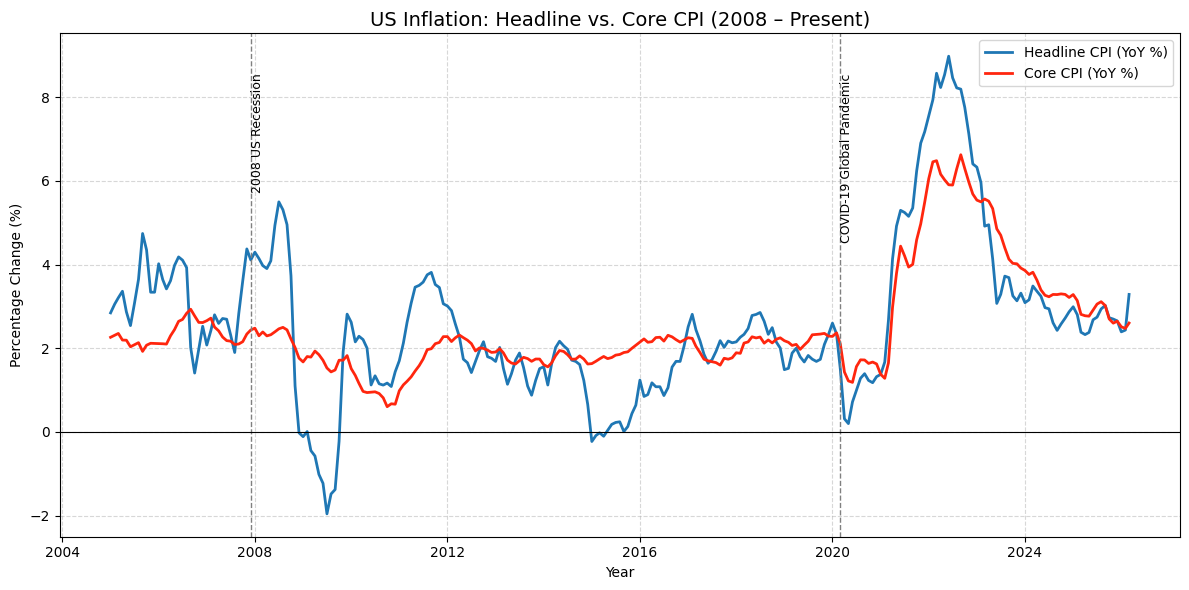

In [ ]:
# Install system dependencies
!pip install pandas-datareader

# Import python libraries
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from datetime import datetime

start = datetime(2004, 1, 1)
end = datetime.now()

# Fetch data from FRED
df = web.DataReader(['CPIAUCSL', 'CPILFESL'], 'fred', start, end)

# Year-over-Year percentage change
df_yoy = df.pct_change(periods=12) * 100

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_yoy.index, df_yoy['CPIAUCSL'], label='Headline CPI (YoY %)', color='#1f77b4', linewidth=2)
plt.plot(df_yoy.index, df_yoy['CPILFESL'], label='Core CPI (YoY %)', color="#ff260e", linewidth=2)

# Critical Event Markers
# 2008 Financial Crisis -- NBER start: Dec 2007
evt_recession = pd.to_datetime('2007-12-01')
plt.axvline(x=evt_recession, color='gray', linestyle='--', linewidth=1)
plt.text(evt_recession, plt.ylim()[1]*0.9, '2008 US Recession',
         rotation=90, verticalalignment='top', fontsize=9)

# COVID-19 Pandemic -- March 2020
evt_covid = pd.to_datetime('2020-03-01')
plt.axvline(x=evt_covid, color='gray', linestyle='--', linewidth=1)
plt.text(evt_covid, plt.ylim()[1]*0.9, 'COVID-19 Global Pandemic',
         rotation=90, verticalalignment='top', fontsize=9)

# Formatting
plt.title('US Inflation: Headline vs. Core CPI (2008 – Present)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()